# Day 1 · 03 · Power BI Data Preparation and Semantic Model Handoff

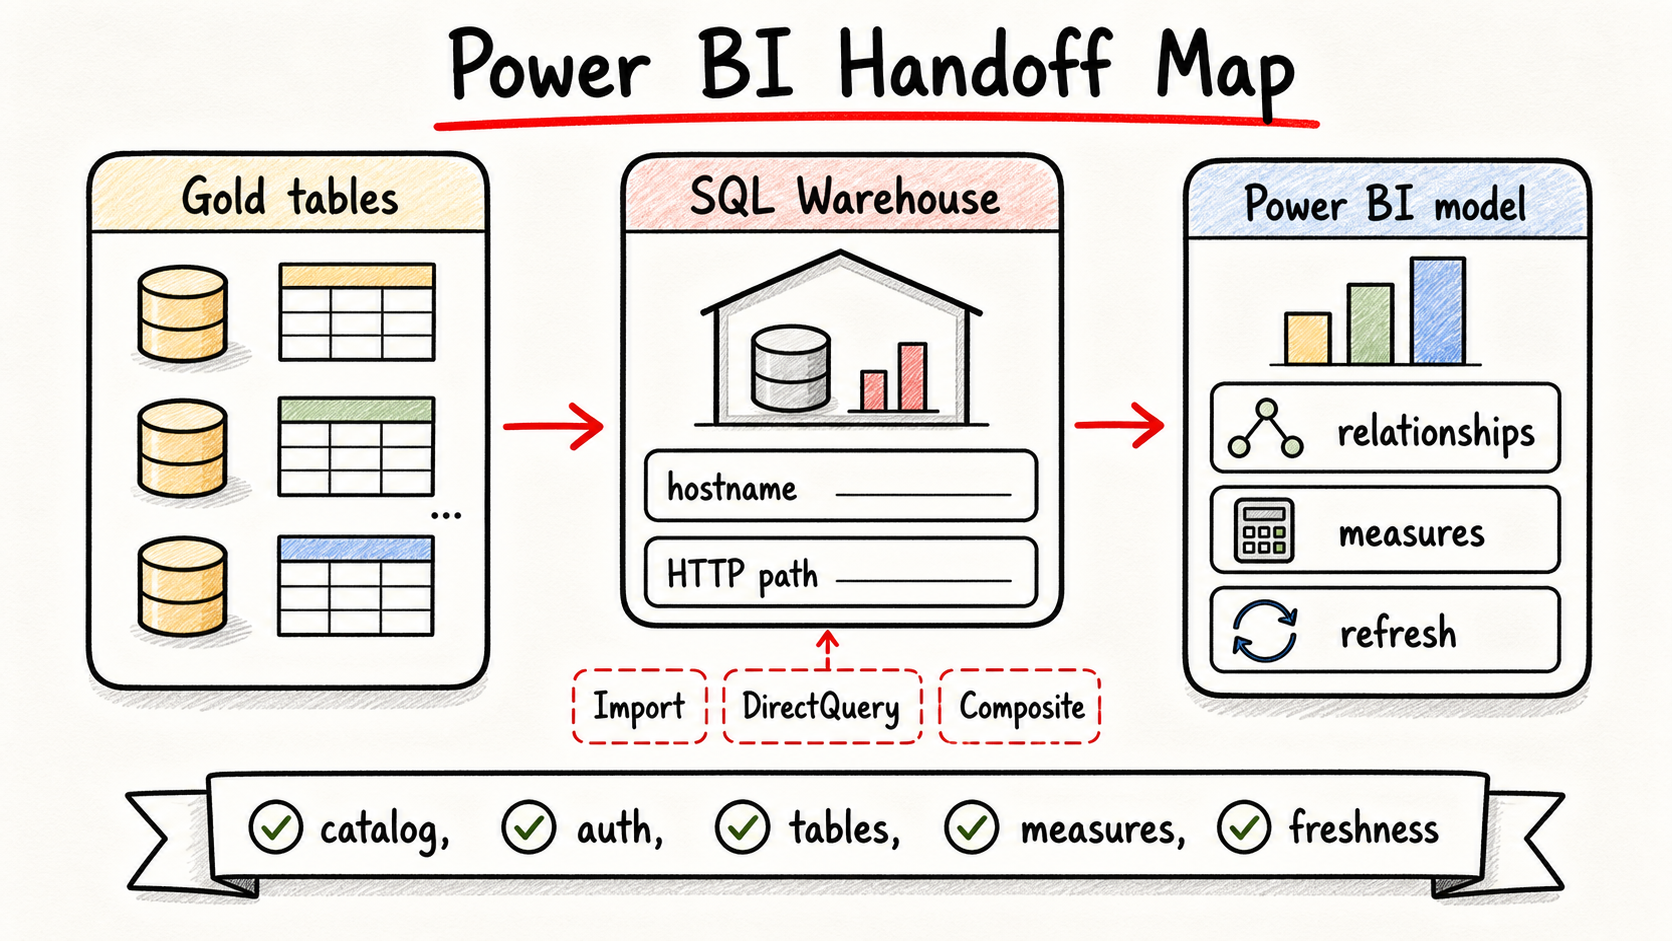

Workshop 1 built the Gold model. This notebook validates that model for Power BI, explains semantic-model decisions and prepares a practical handoff checklist.


## Business Scenario

The BI team now has Gold objects in Databricks. The next decision is not whether Power BI can connect, but what it should connect to, which logic belongs in Databricks, and which logic should remain in the Power BI semantic model.


## Learning Objectives

By the end of this notebook you can:

- validate the Workshop 1 Kimball model,
- confirm grain and relationship readiness,
- choose between a star schema and a flat dashboard table,
- decide what belongs in Databricks Gold vs Power BI DAX or Power Query,
- define baseline KPI measures,
- explain Import, DirectQuery and Composite model tradeoffs,
- prepare a handoff checklist for the Power BI team.


## Setup

Resolve the participant catalog. `00_setup` executes `USE CATALOG`, so SQL cells can use two-part names such as `silver.order_lines`.


In [ ]:
%run ../../setup/00_setup


### Configuration

Confirm the active catalog and schemas before running SQL cells.


In [ ]:
display(spark.createDataFrame([
    ("CATALOG", CATALOG),
    ("BRONZE", BRONZE),
    ("SILVER", SILVER),
    ("GOLD", GOLD),
], ["Variable", "Value"]))


### Runtime Pre-check

Workshop 1 must have created the complete Gold model. If this fails, run `w1_gold_kpi_solution.ipynb` first.


In [ ]:
required_tables = [
    f"{GOLD}.dim_date",
    f"{GOLD}.dim_customer",
    f"{GOLD}.dim_product",
    f"{GOLD}.fact_sales",
    f"{GOLD}.fact_sales_dashboard",
]
missing = [t for t in required_tables if not spark.catalog.tableExists(t)]
if missing:
    for table in missing:
        print("[MISSING]", table)
    raise Exception("Pre-check failed. Complete Workshop 1 before running Day1_03.")
print("[OK] Workshop 1 Gold model is available.")


## 1. Gold Inventory

Start with a concrete inventory. A Power BI handoff should name the catalog, schema, objects and expected row counts.


In [ ]:
%sql
SHOW TABLES IN gold


In [ ]:
%sql
SELECT 'dim_date' AS object_name, COUNT(*) AS rows FROM gold.dim_date
UNION ALL
SELECT 'dim_customer', COUNT(*) FROM gold.dim_customer
UNION ALL
SELECT 'dim_product', COUNT(*) FROM gold.dim_product
UNION ALL
SELECT 'fact_sales', COUNT(*) FROM gold.fact_sales
UNION ALL
SELECT 'fact_sales_dashboard', COUNT(*) FROM gold.fact_sales_dashboard
ORDER BY object_name


## 2. Grain Checks

Power BI visuals break when a table's grain is unclear. The fact and dashboard table should both have one row per `line_id`.


In [ ]:
%sql
SELECT
  'fact_sales' AS object_name,
  COUNT(*) AS rows,
  COUNT(DISTINCT line_id) AS distinct_lines,
  COUNT(*) - COUNT(DISTINCT line_id) AS duplicate_lines,
  COUNT(DISTINCT order_id) AS distinct_orders
FROM gold.fact_sales
UNION ALL
SELECT
  'fact_sales_dashboard',
  COUNT(*),
  COUNT(DISTINCT line_id),
  COUNT(*) - COUNT(DISTINCT line_id),
  COUNT(DISTINCT order_id)
FROM gold.fact_sales_dashboard


## 3. Relationship Readiness

A semantic model relationship needs a unique dimension key and matching fact rows. Check both before connecting Power BI.


In [ ]:
%sql
SELECT 'dim_date' AS dimension, COUNT(*) AS rows, COUNT(DISTINCT date_key) AS distinct_keys, COUNT(*) - COUNT(DISTINCT date_key) AS duplicate_keys
FROM gold.dim_date
UNION ALL
SELECT 'dim_customer', COUNT(*), COUNT(DISTINCT customer_id), COUNT(*) - COUNT(DISTINCT customer_id)
FROM gold.dim_customer
UNION ALL
SELECT 'dim_product', COUNT(*), COUNT(DISTINCT product_id), COUNT(*) - COUNT(DISTINCT product_id)
FROM gold.dim_product


In [ ]:
%sql
SELECT 'fact_sales.order_date -> dim_date.date_key' AS relationship, COUNT(*) AS orphan_rows
FROM gold.fact_sales f
LEFT ANTI JOIN gold.dim_date d ON f.order_date = d.date_key
UNION ALL
SELECT 'fact_sales.customer_id -> dim_customer.customer_id', COUNT(*)
FROM gold.fact_sales f
LEFT ANTI JOIN gold.dim_customer c ON f.customer_id = c.customer_id
UNION ALL
SELECT 'fact_sales.product_id -> dim_product.product_id', COUNT(*)
FROM gold.fact_sales f
LEFT ANTI JOIN gold.dim_product p ON f.product_id = p.product_id


## 4. Star Schema vs Flat Table

![Star schema vs flat table](../../assets/images/star_schema_vs_flat_table.png)

Use the star schema for governed semantic models. Use the flat dashboard table when the training goal is speed, first exploration or a narrow operational report.

| Source option | Best for | Tradeoff |
|---|---|---|
| `gold.fact_sales` + dimensions | reusable semantic model, relationships, governed measures | more modeling work in Power BI |
| `gold.fact_sales_dashboard` | quick report pages and prototypes | duplicated attributes and wider DirectQuery scans |

Expected observation: both options are valid, but they solve different delivery problems.


### Relationship Map

| From table | From column | To table | To column | Cardinality | Cross-filter direction |
|---|---|---|---|---|---|
| `gold.fact_sales` | `order_date` | `gold.dim_date` | `date_key` | many-to-one | single |
| `gold.fact_sales` | `customer_id` | `gold.dim_customer` | `customer_id` | many-to-one | single |
| `gold.fact_sales` | `product_id` | `gold.dim_product` | `product_id` | many-to-one | single |


## 5. Databricks Gold vs Power BI Logic

Keep shared, expensive and governed logic in Databricks. Keep interactive report semantics in Power BI.

| Logic | Prefer Databricks Gold | Prefer Power BI |
|---|---|---|
| joins and conformed attributes | yes | no |
| row-level cleansing and unknown labels | yes | no |
| reusable KPI base columns | yes | sometimes |
| report-specific slicer labels | sometimes | yes |
| visual-specific measures | no | yes |
| ad hoc formatting and presentation | no | yes |
| Power Query transformations over large DirectQuery tables | no | avoid |


## 6. KPI Dictionary

KPI definitions must be explicit before report authors build visuals. Ambiguous filters are the fastest way to create inconsistent dashboards.


In [ ]:
%sql
SELECT
  'Revenue' AS kpi_name,
  'SUM(line_revenue) for completed rows' AS definition,
  'Currency' AS format,
  'gold.fact_sales or gold.fact_sales_dashboard' AS source_object
UNION ALL
SELECT 'Gross Margin', 'SUM(line_margin) for completed rows', 'Currency', 'gold.fact_sales or gold.fact_sales_dashboard'
UNION ALL
SELECT 'Completed Orders', 'DISTINCTCOUNT(order_id) for completed rows', 'Whole number', 'gold.fact_sales or gold.fact_sales_dashboard'
UNION ALL
SELECT 'Margin Rate %', 'Gross Margin divided by Revenue', 'Percentage', 'Power BI measure over Gold fields'
UNION ALL
SELECT 'Return Rate %', 'Returned orders divided by completed + returned orders', 'Percentage', 'Power BI measure over Gold fields'


In [ ]:
%sql
SELECT
  ROUND(SUM(CASE WHEN is_completed THEN line_revenue ELSE 0 END), 2) AS revenue,
  ROUND(SUM(CASE WHEN is_completed THEN line_margin ELSE 0 END), 2) AS gross_margin,
  COUNT(DISTINCT CASE WHEN is_completed THEN order_id END) AS completed_orders,
  ROUND(
    100.0 * SUM(CASE WHEN is_completed THEN line_margin ELSE 0 END)
    / NULLIF(SUM(CASE WHEN is_completed THEN line_revenue ELSE 0 END), 0),
    2
  ) AS margin_rate_pct
FROM gold.fact_sales_dashboard


### Starter DAX Measures

```DAX
Revenue =
CALCULATE (
    SUM ( fact_sales[line_revenue] ),
    fact_sales[is_completed] = TRUE ()
)

Gross Margin =
CALCULATE (
    SUM ( fact_sales[line_margin] ),
    fact_sales[is_completed] = TRUE ()
)

Completed Orders =
CALCULATE (
    DISTINCTCOUNT ( fact_sales[order_id] ),
    fact_sales[is_completed] = TRUE ()
)

Margin Rate % =
DIVIDE ( [Gross Margin], [Revenue] )
```

Expected observation: Databricks supplies governed fields and filters; DAX defines reusable report measures.


## 7. Prepared Preview for Power BI

This temporary view previews a monthly report page without creating another durable Gold object.


In [ ]:
%sql
CREATE OR REPLACE TEMP VIEW powerbi_monthly_preview AS
SELECT
  year_month,
  customer_region,
  category,
  channel,
  ROUND(SUM(CASE WHEN is_completed THEN line_revenue ELSE 0 END), 2) AS revenue,
  ROUND(SUM(CASE WHEN is_completed THEN line_margin ELSE 0 END), 2) AS gross_margin,
  COUNT(DISTINCT CASE WHEN is_completed THEN order_id END) AS completed_orders
FROM gold.fact_sales_dashboard
GROUP BY year_month, customer_region, category, channel


In [ ]:
%sql
SELECT *
FROM powerbi_monthly_preview
ORDER BY year_month DESC, revenue DESC
LIMIT 20


## 8. Import vs DirectQuery vs Composite

![Import vs DirectQuery](../../assets/images/import_vs_directquery.png)

| Mode | Best for | Watch out |
|---|---|---|
| Import | fastest dashboards, scheduled refresh, broad self-service | data freshness depends on refresh |
| DirectQuery | near-real-time reporting and centralized execution | every interaction can trigger warehouse cost |
| Composite | mixed freshness/performance requirements | model complexity and relationship behavior |

Cost intuition: DirectQuery cost follows user interactions, visual fan-out, warehouse size and active time. Import cost follows refresh frequency, model size and refresh complexity.


### Query Folding and Incremental Refresh Awareness

Power Query steps should fold back to Databricks SQL. Filters on dates and simple projections usually fold; custom row-by-row transformations often do not. For Import models, incremental refresh should filter on a stable date column such as `order_date`.


In [ ]:
%sql
EXPLAIN
SELECT
  year_month,
  channel,
  ROUND(SUM(CASE WHEN is_completed THEN line_revenue ELSE 0 END), 2) AS revenue
FROM gold.fact_sales_dashboard
WHERE order_date >= DATE '2024-01-01'
GROUP BY year_month, channel


## 9. Connector Handoff Checklist

| Item | Value or source |
|---|---|
| Catalog | value from the configuration cell |
| Schema | `gold` |
| SQL Warehouse hostname | SQL Warehouses -> Connection details |
| HTTP path | SQL Warehouses -> Connection details |
| Authentication | PAT token or Entra ID, depending on workspace setup |
| First table for quick report | `gold.fact_sales_dashboard` |
| Star schema option | `gold.fact_sales`, `gold.dim_date`, `gold.dim_customer`, `gold.dim_product` |
| Relationships | fact date/customer/product keys to dimensions |
| Recommended measures | revenue, gross margin, completed orders, margin rate, return rate |
| Refresh expectation | align Power BI refresh with Gold refresh job |
| Cost guardrail | avoid wide DirectQuery visuals with many slicers unless latency requires DirectQuery |

Adnotacja: w tym miejscu warto docelowo dodać screenshot lub obraz pokazujący Connection details w SQL Warehouse i mapowanie tych pól w Power BI connectorze.


## Summary and Day 2 Handoff

Day 1 now has a complete path: platform foundation, SQL and architecture patterns, full Kimball workshop and Power BI readiness. Day 2 can focus on performance, dashboards, automation and production handoff instead of rebuilding the model again.
